# Lab 7 — Logistic Regression in Depth
### Predicting Heart Disease with Real Clinical Data

In previous labs we covered the *mechanics* of classification. Today you will put those ideas into practice on a real-world clinical dataset: the **Heart Disease UCI dataset** from the Cleveland Clinic.

Your goal is to build a logistic regression model that predicts whether a patient has heart disease, and to reason carefully about *which metrics matter most* in a medical context.

**Topics covered:**
- Exploratory data analysis (EDA) on real clinical data
- Feature engineering and encoding
- Logistic regression training and coefficient interpretation
- Threshold tuning and its clinical implications
- ROC-AUC analysis
- Cross-validation

Work through each **Exercise** cell. The **Answer** cell directly below contains a solution — try before you peek!

---


## 0. Setup — Run This First

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc,
    precision_score, recall_score, f1_score, accuracy_score
)

# ── Load the Heart Disease UCI dataset directly from the UCI repository ──
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
col_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
    'restecg', 'thalach', 'exang', 'oldpeak',
    'slope', 'ca', 'thal', 'target'
]
df_raw = pd.read_csv(url, header=None, names=col_names, na_values='?')
print(f"Dataset loaded: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
df_raw.head()


Dataset loaded: 303 rows × 14 columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


---
## Section 1 — Exploring the Data

The dataset contains 13 clinical features and one target column.

| Column | Meaning |
|---|---|
| `age` | Age in years |
| `sex` | 1 = male, 0 = female |
| `cp` | Chest pain type (0–3) |
| `trestbps` | Resting blood pressure (mm Hg) |
| `chol` | Serum cholesterol (mg/dl) |
| `fbs` | Fasting blood sugar > 120 mg/dl (1 = true) |
| `restecg` | Resting ECG results (0–2) |
| `thalach` | Maximum heart rate achieved |
| `exang` | Exercise-induced angina (1 = yes) |
| `oldpeak` | ST depression induced by exercise |
| `slope` | Slope of peak exercise ST segment (0–2) |
| `ca` | Number of major vessels coloured by fluoroscopy (0–3) |
| `thal` | Thalassemia type (1 = normal, 2 = fixed defect, 3 = reversable defect) |
| `target` | Original: 0 = no disease, 1–4 = disease severity |

> **Note:** The original `target` column has values 0–4. We will binarise it: **0 = no heart disease, 1 = heart disease present**.


### Exercise 1.1 — Inspect the Data

Use `.info()` and `.describe()` to understand the dataset.
Then print the number of missing values per column.


In [3]:
# ── Your code here ──
print(df_raw.info())

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB
None


In [4]:
print(df_raw.describe())


              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.438944    0.679868    3.158416  131.689769  246.693069    0.148515   
std      9.038662    0.467299    0.960126   17.599748   51.776918    0.356198   
min     29.000000    0.000000    1.000000   94.000000  126.000000    0.000000   
25%     48.000000    0.000000    3.000000  120.000000  211.000000    0.000000   
50%     56.000000    1.000000    3.000000  130.000000  241.000000    0.000000   
75%     61.000000    1.000000    4.000000  140.000000  275.000000    0.000000   
max     77.000000    1.000000    4.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  299.000000   
mean     0.990099  149.607261    0.326733    1.039604    1.600660    0.672241   
std      0.994971   22.8750

**Answer 1.1**

### Exercise 1.2 — Clean and Binarise the Target

1. Drop rows with any missing values.
2. Convert the `target` column so that any value > 0 becomes 1 (heart disease present) and 0 stays 0.
3. Print the new class distribution using `.value_counts()`.


In [5]:
# ── Your code here ──
df_raw=df_raw.dropna()

In [6]:
df_raw.loc[df_raw["target"]>0,"target"] = 1

In [7]:
df_raw.value_counts()

age   sex  cp   trestbps  chol   fbs  restecg  thalach  exang  oldpeak  slope  ca   thal  target
63.0  1.0  1.0  145.0     233.0  1.0  2.0      150.0    0.0    2.3      3.0    0.0  6.0   0         1
67.0  1.0  4.0  160.0     286.0  0.0  2.0      108.0    1.0    1.5      2.0    3.0  3.0   1         1
                120.0     229.0  0.0  2.0      129.0    1.0    2.6      2.0    2.0  7.0   1         1
37.0  1.0  3.0  130.0     250.0  0.0  0.0      187.0    0.0    3.5      3.0    0.0  3.0   0         1
41.0  0.0  2.0  130.0     204.0  0.0  2.0      172.0    0.0    1.4      1.0    0.0  3.0   0         1
                                                                                                   ..
57.0  0.0  4.0  140.0     241.0  0.0  0.0      123.0    1.0    0.2      2.0    0.0  7.0   1         1
45.0  1.0  1.0  110.0     264.0  0.0  0.0      132.0    0.0    1.2      2.0    0.0  7.0   1         1
68.0  1.0  4.0  144.0     193.0  1.0  0.0      141.0    0.0    3.4      2.0    2.0  7.0

**Answer 1.2**

In [8]:
df_raw["target"].value_counts()

target
0    160
1    137
Name: count, dtype: int64

In [9]:
df_raw.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

### Exercise 1.3 — Visualise the Age Distribution by Class

Plot two overlapping histograms — one for patients *without* heart disease and one *with* — using `plt.hist()` with `alpha=0.6`.
Add a legend and axis labels.

**Think about it:** Does older age seem associated with heart disease in this dataset?


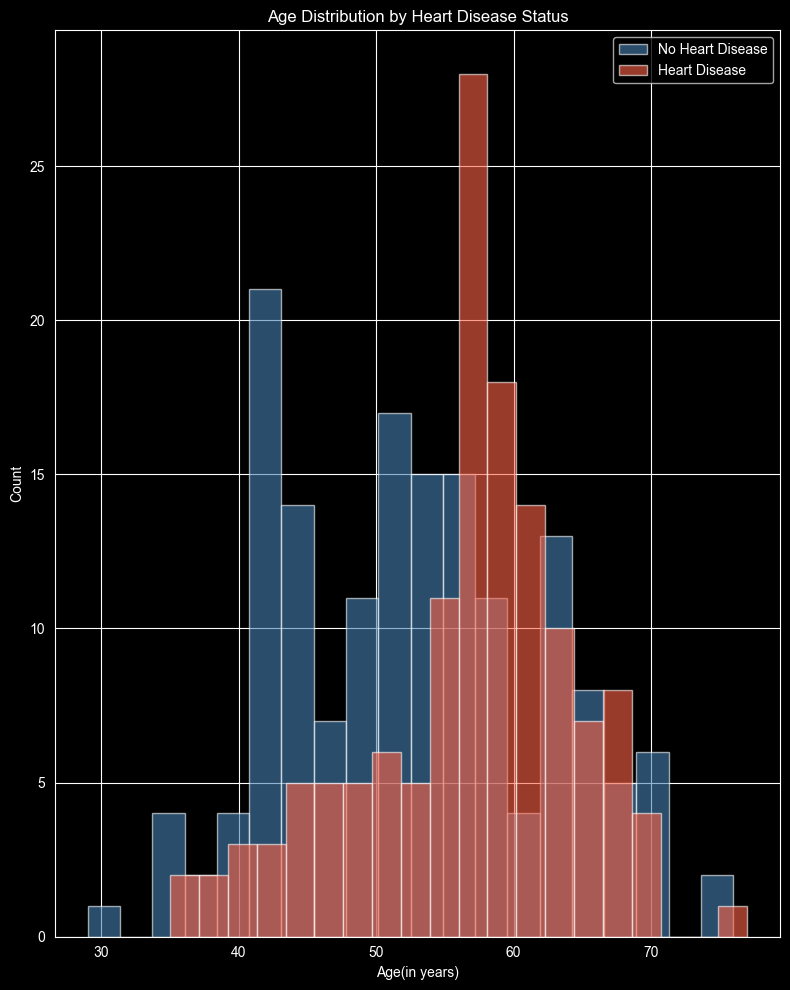

In [10]:
# ── Your code here ──
fig,ax =plt.subplots(figsize=(8,10))
ax.hist(df_raw[df_raw["target"]==0]["age"],bins=20,color="steelblue",alpha=0.6,label="No Heart Disease")
ax.hist(df_raw[df_raw["target"]==1]["age"],bins=20,color="tomato",alpha=0.6,label="Heart Disease")
ax.set_xlabel("Age(in years)")
ax.set_ylabel("Count")
ax.set_title("Age Distribution by Heart Disease Status")
ax.legend()
plt.tight_layout()
plt.show()


**Answer 1.3**

---
## Section 2 — Preprocessing

Before training, we need to:
1. Treat **categorical** features correctly.
2. **Scale** numerical features so that no single feature dominates due to its unit.


### Exercise 2.1 — Identify Categorical vs Numerical Features

The columns `cp`, `restecg`, `slope`, and `thal` look like numbers but are actually **nominal** categories.
Encode them using OneHotEncoder and drop the first dummy to avoid multicollinearity.


In [11]:
# ── Your code here ──
cat_cols =["cp","restecg","slope","thal"]
num_cols =[c for c in df_raw.columns if c not in cat_cols+["target"]]

preprocessor = ColumnTransformer(transformers=[
    ("num",StandardScaler(),num_cols),
    ("cat",OneHotEncoder(drop="first",sparse_output=False),cat_cols)
])


**Answer 2.1**

### Exercise 2.2 — Train/Test Split and Scaling

1. Define `X` (all columns except `target`) and `y` (`target`).
2. Split with `test_size=0.2`, `random_state=42`, and `stratify=y`.
3. Fit a `StandardScaler` **on the training set only**, then transform both train and test sets.
4. Print the shapes of all four arrays.

**Why do we fit the scaler only on training data?**


In [12]:
# ── Your code here ──
X= df_raw.drop('target',axis=1)
y= df_raw["target"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,train_size=0.8,random_state=42,stratify=y)
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)


**Answer 2.2**

---
## Section 3 — Training Logistic Regression


### Exercise 3.1 — Fit the Model

Train a `LogisticRegression` model with default parameters on the scaled training data.
Then:
- Print the training accuracy.
- Print the test accuracy.

**Think:** Is a high training accuracy alone a sign of a good model?


In [13]:
from sklearn.metrics import accuracy_score
# ── Your code here ──
lr = LogisticRegression()

lr.fit(X_train_scaled,y_train)
y_train_pred = lr.predict(X_train_scaled)
y_pred = lr.predict(X_test_scaled)
print(f"Training Accuracy {accuracy_score(y_train,y_train_pred)}")
print(f"Test Accuracy {accuracy_score(y_test,y_pred)}")

Training Accuracy 0.8607594936708861
Test Accuracy 0.85


**Answer 3.1**

### Exercise 3.2 — Interpreting Coefficients

Logistic regression assigns a **coefficient** to each feature. A large positive coefficient means that feature *increases* the log-odds of heart disease; a large negative coefficient means it *decreases* it.

1. Create a `pd.Series` of coefficients, indexed by feature names.
2. Sort by absolute value (descending).
3. Plot a horizontal bar chart of the top 10 most influential features.

**Think:** Which feature has the strongest influence? Does it match your intuition?


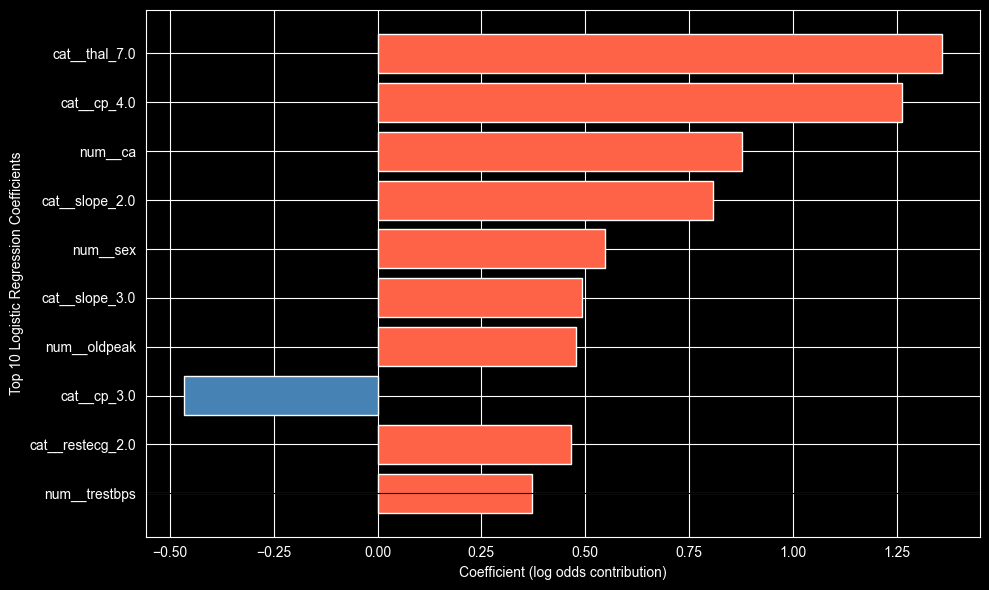

In [14]:
# ── Your code here ──
coefs = pd.Series(lr.coef_[0],index=preprocessor.get_feature_names_out()).sort_values(key=abs,ascending=False)

fig,ax = plt.subplots(figsize =(10,6))
top10 = coefs.head(10)
colors = ["tomato" if c >0 else "steelblue" for c in top10]
ax.barh(top10.index[::-1],top10.values[::-1],color=colors[::-1])
ax.axhline(0,color="black",linewidth=0.8)
ax.set_xlabel("Coefficient (log odds contribution)")
ax.set_ylabel("Top 10 Logistic Regression Coefficients")
plt.tight_layout()
plt.show()

**Answer 3.2**

---
## Section 4 — Evaluation

### Exercise 4.1 — Confusion Matrix

Plot the confusion matrix for predictions made at the **default 0.5 threshold**.
Label the axes `'No Disease (0)'` and `'Heart Disease (1)'`.

From the matrix, manually identify:
- How many true positives (TP)?
- How many false negatives (FN)?


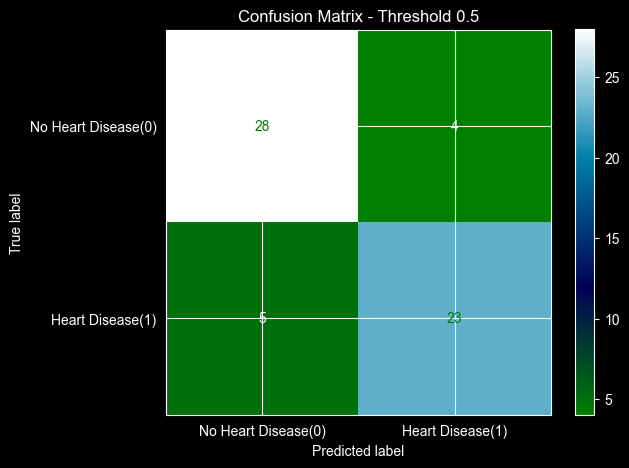

True Negatives  (TN): 28  — correctly predicted No Disease
False Positives (FP): 4  — predicted Disease, actually No Disease
False Negatives (FN): 5  — predicted No Disease, actually Disease  ← dangerous!
True Positives  (TP): 23  — correctly predicted Disease


In [15]:
# ── Your code here ──

cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["No Heart Disease(0)","Heart Disease(1)"])

disp.plot(cmap="ocean")
plt.title("Confusion Matrix - Threshold 0.5")
plt.tight_layout()
plt.show()

tn,fp,fn,tp = cm.ravel()
print(f"True Negatives  (TN): {tn}  — correctly predicted No Disease")
print(f"False Positives (FP): {fp}  — predicted Disease, actually No Disease")
print(f"False Negatives (FN): {fn}  — predicted No Disease, actually Disease  ← dangerous!")
print(f"True Positives  (TP): {tp}  — correctly predicted Disease")

**Answer 4.1**

### Exercise 4.2 — Precision, Recall, and F1

Print the full `classification_report` for the default-threshold predictions.

Then answer these questions in comments or a markdown cell:
1. What is the Recall for the heart disease class (class 1)?
2. In a clinical screening tool, which metric is more important — Precision or Recall? Why?


In [16]:
# ── Your code here ──
print(classification_report(y_test,y_pred,target_names =["No Heart Disease(0)","Heart Disease(1)"]))


                     precision    recall  f1-score   support

No Heart Disease(0)       0.85      0.88      0.86        32
   Heart Disease(1)       0.85      0.82      0.84        28

           accuracy                           0.85        60
          macro avg       0.85      0.85      0.85        60
       weighted avg       0.85      0.85      0.85        60



**Answer 4.2**

**Discussion:**

- **Recall** tells us: *"Of all the patients who actually have heart disease, how many did we correctly catch?"*
- A **False Negative** (missing a real case) means a sick patient is sent home untreated — potentially life-threatening.
- A **False Positive** (flagging a healthy patient) leads to follow-up tests — inconvenient but not dangerous.

Therefore, in clinical screening, **Recall is more important than Precision**. We prefer to over-diagnose rather than miss a real case.


### Exercise 4.3 — Threshold Tuning

The default threshold is 0.5. Lower the threshold to **0.35** and repeat:
1. Generate new predictions using `predict_proba`.
2. Plot the confusion matrix.
3. Print Precision, Recall, and F1 for class 1.

Compare the results to the 0.5 threshold. What changed and why?


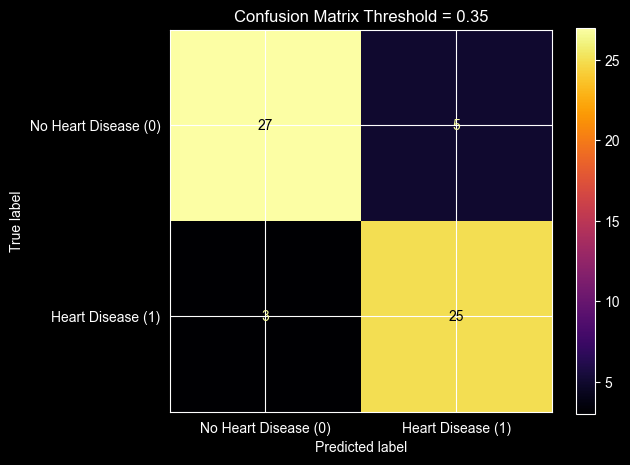

Metric         Threshold=0.50   Threshold=0.35
----------------------------------------------
Precision              0.8519           0.8333
Recall                 0.8214           0.8929
F1-Score               0.8364           0.8621

Lowering the threshold → the model flags more patients as positive.
→ Recall goes UP (we miss fewer real cases).
→ Precision goes DOWN (more false alarms).
This is the fundamental Precision–Recall trade-off.


In [17]:
# ── Your code here ──
y_proba = lr.predict_proba(X_test_scaled)[:,-1]
threshold = 0.35
y_pred_35 = (y_proba >= threshold).astype(int)

cm35 = confusion_matrix(y_test,y_pred_35)
disp35 = ConfusionMatrixDisplay(confusion_matrix=cm35,display_labels=["No Heart Disease (0)","Heart Disease (1)"])

disp35.plot(cmap="inferno")
plt.title("Confusion Matrix Threshold = 0.35")
plt.tight_layout()
plt.show()

p35 = precision_score(y_test, y_pred_35)
r35 = recall_score(y_test, y_pred_35)
f35 = f1_score(y_test, y_pred_35)

p50 = precision_score(y_test, y_pred)
r50 = recall_score(y_test, y_pred)
f50 = f1_score(y_test, y_pred)

print(f"{'Metric':<12} {'Threshold=0.50':>16} {'Threshold=0.35':>16}")
print("-" * 46)
print(f"{'Precision':<12} {p50:>16.4f} {p35:>16.4f}")
print(f"{'Recall':<12} {r50:>16.4f} {r35:>16.4f}")
print(f"{'F1-Score':<12} {f50:>16.4f} {f35:>16.4f}")
print()
print("Lowering the threshold → the model flags more patients as positive.")
print("→ Recall goes UP (we miss fewer real cases).")
print("→ Precision goes DOWN (more false alarms).")
print("This is the fundamental Precision–Recall trade-off.")

**Answer 4.3**

---
## Section 5 — ROC Curve and AUC

### Exercise 5.1 — Plot the ROC Curve

Using the raw predicted *probabilities* (not the hard labels), plot the ROC curve.

1. Compute `fpr`, `tpr`, and `thresholds` using `roc_curve`.
2. Compute the AUC using `auc(fpr, tpr)`.
3. Plot the curve with the AUC value in the legend.
4. Add a dashed diagonal line representing random guessing.

**What does an AUC of 1.0 mean? What does 0.5 mean?**


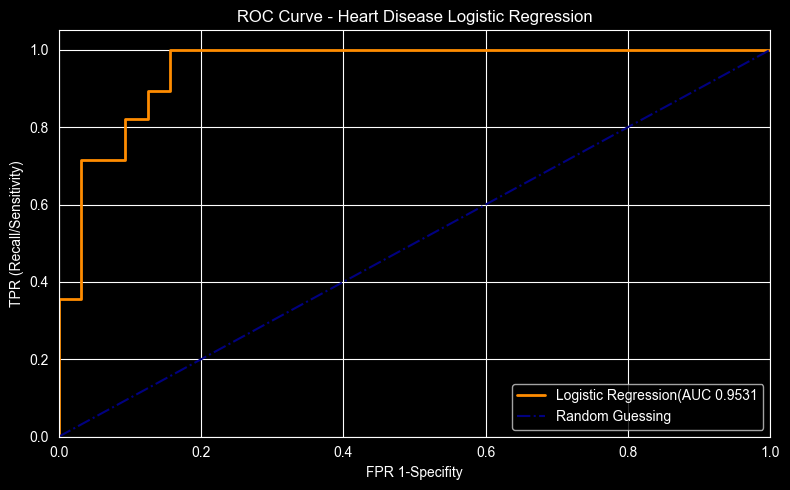

In [33]:
# ── Your code here ──
fpr,tpr,thresholds = roc_curve(y_test,y_proba)
roc_auc = auc(fpr,tpr)
fig,ax= plt.subplots(figsize=(8,5))
ax.plot(fpr,tpr,color="darkorange",lw=2,label=f"Logistic Regression(AUC {roc_auc:.4f}")
ax.plot([0,1],[0,1],color="navy",lw=1.5,linestyle="-.",label="Random Guessing")
ax.set_xlim([0.0,1.0])
ax.set_ylim([0.0,1.05])
ax.set_xlabel("FPR 1-Specifity")
ax.set_ylabel("TPR (Recall/Sensitivity)")
ax.set_title("ROC Curve - Heart Disease Logistic Regression")
ax.legend()
plt.tight_layout()
plt.show()


**Answer 5.1**

### Exercise 5.2 — Finding the Optimal Threshold on the ROC Curve

One practical way to pick a threshold is to find the point on the ROC curve that is **closest to the top-left corner** (highest TPR, lowest FPR).

1. Compute the Euclidean distance from each (fpr, tpr) point to the ideal corner (0, 1).
2. Find the threshold at that closest point.
3. Print the optimal threshold and compute Recall and Precision at that threshold.


In [35]:
# ── Your code here ──
distances = np.sqrt(fpr**2+(1-tpr)**2)
best_idx = np.argmin(distances)
best_threshold = thresholds[best_idx]

print(f"Optimal Threshold {best_threshold:.4f}")
print(f"TPR (Recall) at this point {tpr[best_idx]:.4f}")
print(f"FPR at this point {fpr[best_idx]:.4f}")

y_pred_opt = (y_proba>=best_threshold).astype(int)
print("Precision,Recall,F1 Score's at optimal threshold")
print(f"Precision {precision_score(y_test,y_pred_opt)}")
print(f"Recall {recall_score(y_test,y_pred_opt)}")
print(f"F1 {f1_score(y_test,y_pred_opt)}")

Optimal Threshold 0.2562
TPR (Recall) at this point 1.0000
FPR at this point 0.1562
Precision,Recall,F1 Score's at optimal threshold
Precision 0.8484848484848485
Recall 1.0
F1 0.9180327868852459


**Answer 5.2**

---
## Section 6 — Cross-Validation

### Exercise 6.1 — 5-Fold Stratified Cross-Validation

A single train/test split can be lucky or unlucky. Cross-validation gives a more robust estimate of model performance.

1. Use `cross_val_score` with `cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`.
2. Score with **both** `'roc_auc'` and `'recall'`.
3. Print the individual fold scores and the mean ± standard deviation for each metric.

> **Hint:** Scale inside CV properly — fit the scaler on each fold's training portion. Here, for simplicity, use the pre-scaled `X_all_sc` defined below.


In [36]:
# Pre-scale the entire dataset for cross-validation (demo purposes)
# In production, wrap scaler + model in a Pipeline
X_all_sc = StandardScaler().fit_transform(X)
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_model = LogisticRegression(random_state=42,max_iter=1000)

auc_scores = cross_val_score(cv_model,X_all_sc,y,cv=cv,scoring="roc_auc")
recall_scores = cross_val_score(cv_model,X_all_sc,y,cv=cv,scoring="recall")

print("── 5-Fold Stratified Cross-Validation ──")
print()
print("ROC-AUC per fold :", np.round(auc_scores, 4))
print(f"Mean AUC         : {auc_scores.mean():.4f}  ±  {auc_scores.std():.4f}")
print()
print("Recall per fold  :", np.round(recall_scores, 4))
print(f"Mean Recall      : {recall_scores.mean():.4f}  ±  {recall_scores.std():.4f}")
print()
print("Low standard deviation → the model generalises consistently across folds.")

# ── Your code here ──


── 5-Fold Stratified Cross-Validation ──

ROC-AUC per fold : [0.9386 0.9118 0.8345 0.8588 0.9248]
Mean AUC         : 0.8937  ±  0.0401

Recall per fold  : [0.8929 0.75   0.7037 0.6667 0.8148]
Mean Recall      : 0.7656  ±  0.0806

Low standard deviation → the model generalises consistently across folds.


**Answer 6.1**

In [21]:
# ── Your code here ──

---
## Section 7 — Challenge: Putting It All Together

### Challenge Exercise — Full Pipeline Report

Write a function `evaluate_model(threshold)` that:
1. Generates predictions from `y_proba` at the given threshold.
2. Prints the confusion matrix.
3. Prints Precision, Recall, F1, and Accuracy for class 1.
4. Returns a dictionary with those four values.

Then call it for thresholds `[0.30, 0.40, 0.50, 0.60]` and build a summary `pd.DataFrame` showing how each metric changes with the threshold.

Which threshold would *you* recommend for a hospital screening tool? Justify your answer.


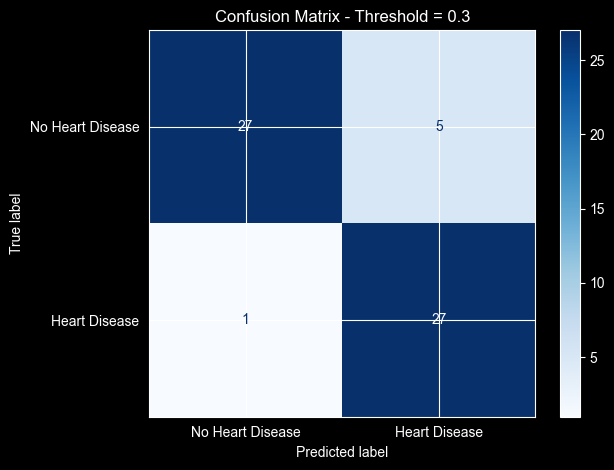

  Precision=0.844  Recall=0.964  F1=0.900  Accuracy=0.900



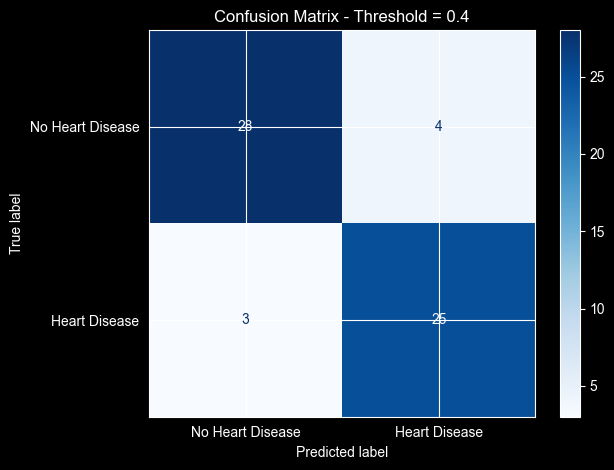

  Precision=0.862  Recall=0.893  F1=0.877  Accuracy=0.883



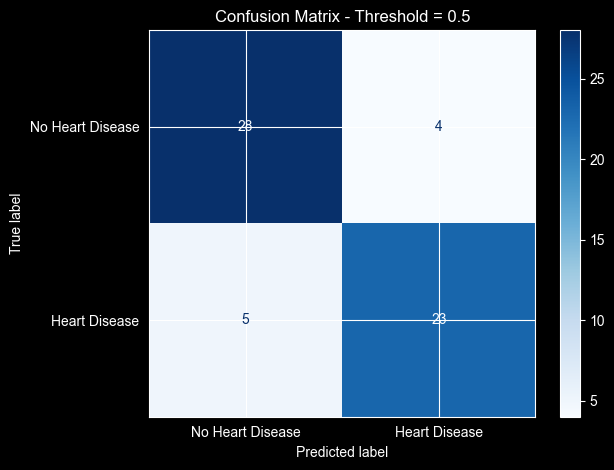

  Precision=0.852  Recall=0.821  F1=0.836  Accuracy=0.850



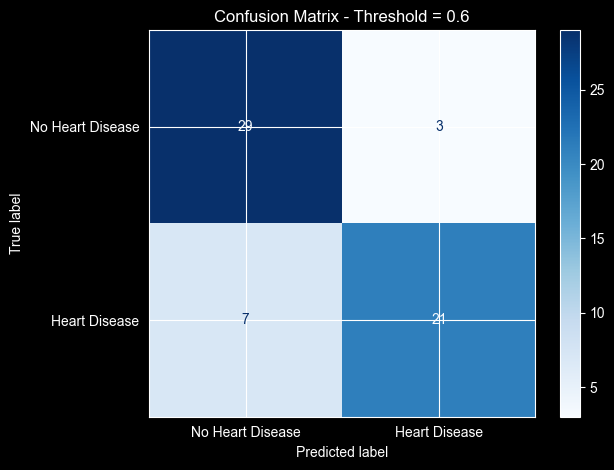

  Precision=0.875  Recall=0.750  F1=0.808  Accuracy=0.833

Summary Table
           precision  recall     f1  accuracy
threshold                                    
0.3            0.844   0.964  0.900     0.900
0.4            0.862   0.893  0.877     0.883
0.5            0.852   0.821  0.836     0.850
0.6            0.875   0.750  0.808     0.833


In [37]:
# ── Your code here ──
def evaluate_model(threshold):
    y_pred_t = (y_proba >=threshold).astype(int)
    cm_t= confusion_matrix(y_test,y_pred_t)
    disp_t = ConfusionMatrixDisplay(confusion_matrix=cm_t,display_labels=["No Heart Disease","Heart Disease"])
    disp_t.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - Threshold = {threshold}")
    plt.tight_layout()
    plt.show()

    p=precision_score(y_test,y_pred_t,zero_division=0)
    r=recall_score(y_test,y_pred_t,zero_division=0)
    f=f1_score(y_test,y_pred_t,zero_division=0)
    a = (y_pred_t == y_test).mean()
    print(f"  Precision={p:.3f}  Recall={r:.3f}  F1={f:.3f}  Accuracy={a:.3f}\n")
    return {'threshold': threshold, 'precision': p, 'recall': r, 'f1': f, 'accuracy': a}

thresholds_to_try = [0.30,0.40,0.50,0.60]
results = [evaluate_model(t) for t in thresholds_to_try]
summary = pd.DataFrame(results).set_index("threshold")
print("Summary Table")
print(summary.round(3))





---
## Summary

In this lab you:

| Step | What you did |
|---|---|
| **EDA** | Loaded real clinical data, handled missing values, binarised the target |
| **Preprocessing** | One-hot encoded categorical features, applied `StandardScaler` correctly |
| **Training** | Fit `LogisticRegression` and interpreted its coefficients |
| **Evaluation** | Read a confusion matrix, computed Precision, Recall, F1 |
| **Threshold tuning** | Saw how lowering the threshold trades Precision for Recall |
| **ROC / AUC** | Plotted the ROC curve and found the geometrically optimal threshold |
| **Cross-validation** | Estimated generalisation performance with 5-fold CV |

**Key takeaway:** In medical (and many other high-stakes) contexts, accuracy alone is misleading.
Always report Recall, Precision, and AUC — and choose your threshold deliberately based on the *cost* of each type of error.
